# MNIST Small Dataset Exploration

This notebook explores at what dataset size the classifier starts to fail.
We use the exact same architecture as in the DP Opacus notebook but train without DP (centralized learning).

## 1. Setup and Imports

In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, TensorDataset, Subset
import matplotlib.pyplot as plt
from typing import Tuple, Optional, Dict, List
import pandas as pd
from tqdm import tqdm
import os
from sklearn.model_selection import train_test_split
from torchvision import datasets, transforms

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"CUDA device: {torch.cuda.get_device_name(0)}")

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Set random seeds for reproducibility
SEED = 417
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

PyTorch version: 2.9.1+cu128
CUDA available: True
CUDA device: NVIDIA RTX A1000 6GB Laptop GPU
Using device: cuda


## 2. Data Loading and Preprocessing

In [2]:
def load_mnist_with_splits(seed: int = 417) -> Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    """
    Load MNIST data with exact splits as described in thesis.
    
    Returns:
        X_train, y_train, X_val, y_val, X_test, y_test
    """
    # Load MNIST using torchvision
    mnist_train = datasets.MNIST(root='../../data', train=True, download=True)
    mnist_test = datasets.MNIST(root='../../data', train=False, download=True)
    
    # Combine original train and test to get full 70,000 samples
    X_full = np.concatenate([mnist_train.data.numpy(), mnist_test.data.numpy()], axis=0)
    y_full = np.concatenate([mnist_train.targets.numpy(), mnist_test.targets.numpy()], axis=0)
    
    print(f"Total samples: {len(X_full)}")
    
    # First split: 20% for test
    X_temp, X_test, y_temp, y_test = train_test_split(
        X_full, y_full, test_size=0.2, random_state=seed, stratify=y_full
    )
    
    # Second split: From remaining 80%, take 20% for validation (= 16% of original)
    X_train, X_val, y_train, y_val = train_test_split(
        X_temp, y_temp, test_size=0.2, random_state=seed, stratify=y_temp
    )
    
    print(f"Train samples: {len(X_train)}")
    print(f"Validation samples: {len(X_val)}")
    print(f"Test samples: {len(X_test)}")
    
    return X_train, y_train, X_val, y_val, X_test, y_test

# Load data
X_train_full, y_train_full, X_val, y_val, X_test, y_test = load_mnist_with_splits(SEED)

Total samples: 70000
Train samples: 44800
Validation samples: 11200
Test samples: 14000


In [3]:
def preprocess_mnist(X_train, y_train, X_val, y_val, X_test, y_test):
    """
    Preprocess MNIST data:
    - Normalize pixel values to [0, 1]
    - Add channel dimension for CNN
    - Convert to PyTorch tensors
    """
    # Normalize to [0, 1]
    X_train = X_train.astype('float32') / 255.0
    X_val = X_val.astype('float32') / 255.0
    X_test = X_test.astype('float32') / 255.0
    
    # Add channel dimension (28, 28) -> (1, 28, 28) for PyTorch
    X_train = np.expand_dims(X_train, 1)
    X_val = np.expand_dims(X_val, 1)
    X_test = np.expand_dims(X_test, 1)
    
    # Convert to PyTorch tensors
    X_train = torch.FloatTensor(X_train)
    X_val = torch.FloatTensor(X_val)
    X_test = torch.FloatTensor(X_test)
    
    y_train = torch.LongTensor(y_train)
    y_val = torch.LongTensor(y_val)
    y_test = torch.LongTensor(y_test)
    
    return X_train, y_train, X_val, y_val, X_test, y_test

X_train_full, y_train_full, X_val, y_val, X_test, y_test = preprocess_mnist(
    X_train_full, y_train_full, X_val, y_val, X_test, y_test
)

print(f"X_train_full shape: {X_train_full.shape}")
print(f"X_val shape: {X_val.shape}")
print(f"X_test shape: {X_test.shape}")

X_train_full shape: torch.Size([44800, 1, 28, 28])
X_val shape: torch.Size([11200, 1, 28, 28])
X_test shape: torch.Size([14000, 1, 28, 28])


## 3. Model Architecture

Same architecture as the DP Opacus notebook.

In [4]:
class MNIST_CNN(nn.Module):
    """
    CNN architecture from thesis section 3.3.2.
    """
    def __init__(self, use_dropout: bool = False, dropout_rate: float = 0.1):
        super(MNIST_CNN, self).__init__()
        
        self.use_dropout = use_dropout
        self.dropout_rate = dropout_rate
        
        # First convolutional block
        self.conv1_1 = nn.Conv2d(1, 32, kernel_size=5, padding=2)
        self.conv1_2 = nn.Conv2d(32, 32, kernel_size=5, padding=2)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)
        
        # Second convolutional block
        self.conv2_1 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.conv2_2 = nn.Conv2d(64, 64, kernel_size=3, padding=1)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)
        
        # After convolutions: 28 -> 14 -> 7, so 7x7x64 = 3136
        self.fc1 = nn.Linear(64 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, 10)
        
        # Dropout layers
        if self.use_dropout:
            self.dropout1 = nn.Dropout(dropout_rate)
            self.dropout2 = nn.Dropout(dropout_rate)
            self.dropout3 = nn.Dropout(dropout_rate)
    
    def forward(self, x):
        # First convolutional block
        x = F.relu(self.conv1_1(x))
        x = F.relu(self.conv1_2(x))
        x = self.pool1(x)
        if self.use_dropout:
            x = self.dropout1(x)
        
        # Second convolutional block
        x = F.relu(self.conv2_1(x))
        x = F.relu(self.conv2_2(x))
        x = self.pool2(x)
        if self.use_dropout:
            x = self.dropout2(x)
        
        # Flatten
        x = x.view(x.size(0), -1)
        
        # Dense layers
        x = F.relu(self.fc1(x))
        if self.use_dropout:
            x = self.dropout3(x)
        
        # Output
        x = self.fc2(x)
        
        return x

# Test model
model = MNIST_CNN(use_dropout=False)
print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")

Model parameters: 484,714


## 4. Training Functions

In [5]:
def train_one_epoch(model, dataloader, optimizer, criterion, device):
    """Train for one epoch."""
    model.train()
    total_loss = 0.0
    correct = 0
    total = 0
    
    for data, target in dataloader:
        data, target = data.to(device), target.to(device)
        
        optimizer.zero_grad()
        output = model(data)
        loss = criterion(output, target)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item() * data.size(0)
        pred = output.argmax(dim=1, keepdim=True)
        correct += pred.eq(target.view_as(pred)).sum().item()
        total += data.size(0)
    
    return total_loss / total, correct / total


def evaluate(model, dataloader, criterion, device):
    """Evaluate model."""
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for data, target in dataloader:
            data, target = data.to(device), target.to(device)
            
            output = model(data)
            loss = criterion(output, target)
            
            total_loss += loss.item() * data.size(0)
            pred = output.argmax(dim=1, keepdim=True)
            correct += pred.eq(target.view_as(pred)).sum().item()
            total += data.size(0)
    
    return total_loss / total, correct / total

In [6]:
def train_model(model, 
                train_loader,
                val_loader,
                epochs: int = 40,
                learning_rate: float = 0.001,
                device: torch.device = device,
                verbose: bool = True) -> Dict:
    """
    Train model with standard (non-DP) SGD.
    """
    model = model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    criterion = nn.CrossEntropyLoss()
    
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    
    for epoch in range(epochs):
        train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
        val_loss, val_acc = evaluate(model, val_loader, criterion, device)
        
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        
        if verbose and ((epoch + 1) % 10 == 0 or epoch == 0):
            print(f"Epoch {epoch+1}/{epochs} - Loss: {train_loss:.4f} - Acc: {train_acc:.4f} - Val Acc: {val_acc:.4f}")
    
    return history

## 5. Small Dataset Experiments

We'll test different training set sizes to find where the model starts struggling.

In [7]:
def create_subset_dataloaders(X_train, y_train, X_val, y_val, X_test, y_test, 
                               train_size: int, batch_size: int = 64, seed: int = SEED):
    """
    Create dataloaders with a subset of the training data.
    Uses stratified sampling to maintain class balance when possible.
    For very small sizes (< 10), uses random sampling.
    """
    np.random.seed(seed)
    
    if train_size >= len(X_train):
        # Use full training set
        X_train_subset = X_train
        y_train_subset = y_train
    elif train_size < 10:
        # For very small sizes, just randomly sample
        all_indices = np.arange(len(X_train))
        indices = np.random.choice(all_indices, size=train_size, replace=False)
        X_train_subset = X_train[indices]
        y_train_subset = y_train[indices]
    else:
        # Stratified subset - ensure at least 1 sample per class
        indices = []
        samples_per_class = max(1, train_size // 10)
        remaining = train_size - (samples_per_class * 10)
        
        for c in range(10):
            class_indices = np.where(y_train.numpy() == c)[0]
            # Add extra samples to first few classes if needed
            n_samples = samples_per_class + (1 if c < remaining else 0)
            selected = np.random.choice(class_indices, size=min(n_samples, len(class_indices)), replace=False)
            indices.extend(selected)
        
        indices = np.array(indices)
        np.random.shuffle(indices)
        
        X_train_subset = X_train[indices]
        y_train_subset = y_train[indices]
    
    train_dataset = TensorDataset(X_train_subset, y_train_subset)
    val_dataset = TensorDataset(X_val, y_val)
    test_dataset = TensorDataset(X_test, y_test)
    
    # Adjust batch size if needed for very small datasets
    effective_batch_size = min(batch_size, len(train_dataset))
    
    train_loader = DataLoader(train_dataset, batch_size=effective_batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
    
    return train_loader, val_loader, test_loader

In [8]:
# Dataset sizes to test
# Start with very small sizes and go up to larger ones
dataset_sizes = [5,20,50, 100, 200, 500, 1000, 2000, 5000, 10000, 20000, 44800]

print(f"Testing {len(dataset_sizes)} different dataset sizes: {dataset_sizes}")

Testing 12 different dataset sizes: [5, 20, 50, 100, 200, 500, 1000, 2000, 5000, 10000, 20000, 44800]


In [9]:
# Run experiments
results = []
all_histories = {}

EPOCHS = 50
BATCH_SIZE = 64
LEARNING_RATE = 0.001

for size in dataset_sizes:
    print(f"\n{'='*60}")
    print(f"Training with {size} samples")
    print(f"{'='*60}")
    
    # Create dataloaders
    train_loader, val_loader, test_loader = create_subset_dataloaders(
        X_train_full, y_train_full, X_val, y_val, X_test, y_test,
        train_size=size, batch_size=BATCH_SIZE
    )
    
    print(f"Actual training samples: {len(train_loader.dataset)}")
    print(f"Samples per class: ~{len(train_loader.dataset) // 10}")
    
    # Create fresh model
    model = MNIST_CNN(use_dropout=False).to(device)
    
    # Train
    history = train_model(
        model, train_loader, val_loader,
        epochs=EPOCHS,
        learning_rate=LEARNING_RATE,
        verbose=True
    )
    
    # Evaluate on test set
    criterion = nn.CrossEntropyLoss()
    test_loss, test_acc = evaluate(model, test_loader, criterion, device)
    
    print(f"\nFinal Test Accuracy: {test_acc:.4f}")
    
    # Store results
    results.append({
        'dataset_size': size,
        'final_train_acc': history['train_acc'][-1],
        'final_val_acc': history['val_acc'][-1],
        'final_test_acc': test_acc,
        'best_val_acc': max(history['val_acc']),
        'final_train_loss': history['train_loss'][-1],
        'final_val_loss': history['val_loss'][-1],
        'test_loss': test_loss
    })
    
    all_histories[size] = history


Training with 5 samples
Actual training samples: 5
Samples per class: ~0
Epoch 1/50 - Loss: 2.2951 - Acc: 0.0000 - Val Acc: 0.1081
Epoch 10/50 - Loss: 1.1896 - Acc: 0.4000 - Val Acc: 0.2446
Epoch 20/50 - Loss: 0.1634 - Acc: 0.8000 - Val Acc: 0.3035
Epoch 30/50 - Loss: 0.0006 - Acc: 1.0000 - Val Acc: 0.2752
Epoch 40/50 - Loss: 0.0000 - Acc: 1.0000 - Val Acc: 0.3082
Epoch 50/50 - Loss: 0.0000 - Acc: 1.0000 - Val Acc: 0.3096

Final Test Accuracy: 0.3088

Training with 20 samples
Actual training samples: 20
Samples per class: ~2
Epoch 1/50 - Loss: 2.3030 - Acc: 0.1000 - Val Acc: 0.1029
Epoch 10/50 - Loss: 0.8892 - Acc: 0.8500 - Val Acc: 0.4283
Epoch 20/50 - Loss: 0.0041 - Acc: 1.0000 - Val Acc: 0.4375
Epoch 30/50 - Loss: 0.0004 - Acc: 1.0000 - Val Acc: 0.3993
Epoch 40/50 - Loss: 0.0001 - Acc: 1.0000 - Val Acc: 0.4068
Epoch 50/50 - Loss: 0.0000 - Acc: 1.0000 - Val Acc: 0.4178

Final Test Accuracy: 0.4171

Training with 50 samples
Actual training samples: 50
Samples per class: ~5
Epoch 1/50

## 6. Results Analysis

In [10]:
# Create results dataframe
results_df = pd.DataFrame(results)
print("\n" + "="*80)
print("SUMMARY OF RESULTS")
print("="*80)
print(results_df.to_string(index=False))


SUMMARY OF RESULTS
 dataset_size  final_train_acc  final_val_acc  final_test_acc  best_val_acc  final_train_loss  final_val_loss  test_loss
            5         1.000000       0.309554        0.308786      0.310000      1.916794e-05       49.229912  48.877220
           20         1.000000       0.417768        0.417071      0.470000      3.304253e-05        8.494680   8.459541
           50         1.000000       0.693839        0.700214      0.706071      6.922664e-05        3.463875   3.383104
          100         1.000000       0.808393        0.809214      0.810982      6.285676e-05        1.936892   1.970388
          200         1.000000       0.894286        0.899571      0.894732      2.443779e-04        0.645793   0.642746
          500         1.000000       0.924196        0.926929      0.925625      2.707158e-05        0.570510   0.572181
         1000         1.000000       0.952232        0.952071      0.952768      2.901269e-05        0.348838   0.348863
         200

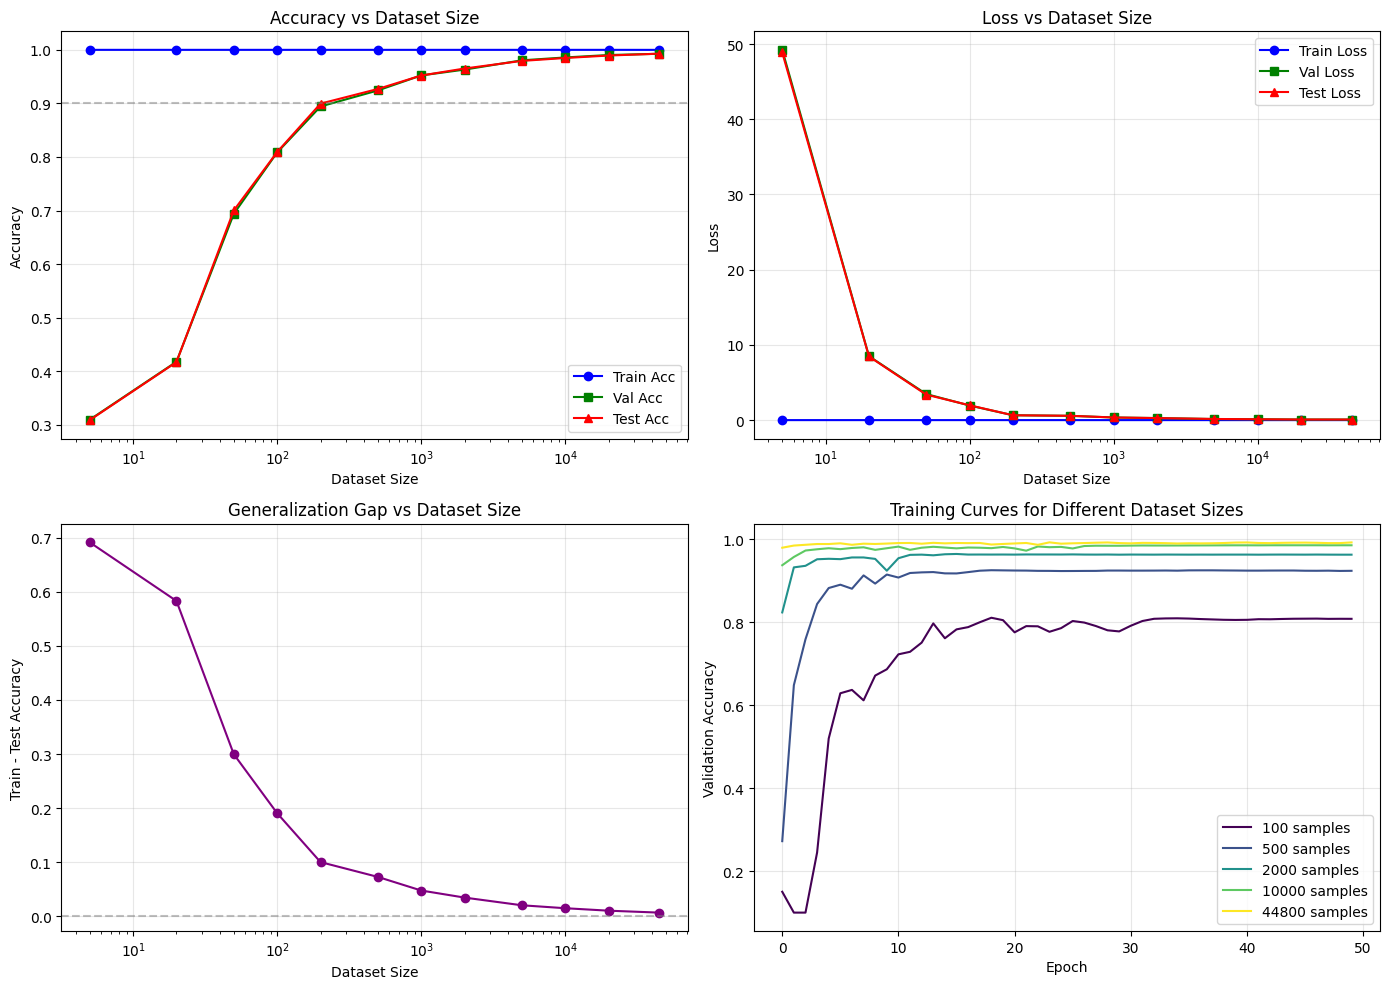

In [11]:
# Plot results
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Accuracy vs Dataset Size
ax1 = axes[0, 0]
ax1.plot(results_df['dataset_size'], results_df['final_train_acc'], 'b-o', label='Train Acc')
ax1.plot(results_df['dataset_size'], results_df['final_val_acc'], 'g-s', label='Val Acc')
ax1.plot(results_df['dataset_size'], results_df['final_test_acc'], 'r-^', label='Test Acc')
ax1.set_xlabel('Dataset Size')
ax1.set_ylabel('Accuracy')
ax1.set_title('Accuracy vs Dataset Size')
ax1.set_xscale('log')
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.axhline(y=0.9, color='gray', linestyle='--', alpha=0.5, label='90% threshold')

# Loss vs Dataset Size
ax2 = axes[0, 1]
ax2.plot(results_df['dataset_size'], results_df['final_train_loss'], 'b-o', label='Train Loss')
ax2.plot(results_df['dataset_size'], results_df['final_val_loss'], 'g-s', label='Val Loss')
ax2.plot(results_df['dataset_size'], results_df['test_loss'], 'r-^', label='Test Loss')
ax2.set_xlabel('Dataset Size')
ax2.set_ylabel('Loss')
ax2.set_title('Loss vs Dataset Size')
ax2.set_xscale('log')
ax2.legend()
ax2.grid(True, alpha=0.3)

# Generalization Gap (Train-Test Acc difference)
ax3 = axes[1, 0]
gap = results_df['final_train_acc'] - results_df['final_test_acc']
ax3.plot(results_df['dataset_size'], gap, 'purple', marker='o')
ax3.set_xlabel('Dataset Size')
ax3.set_ylabel('Train - Test Accuracy')
ax3.set_title('Generalization Gap vs Dataset Size')
ax3.set_xscale('log')
ax3.grid(True, alpha=0.3)
ax3.axhline(y=0, color='gray', linestyle='--', alpha=0.5)

# Training curves for selected sizes
ax4 = axes[1, 1]
selected_sizes = [100, 500, 2000, 10000, 44800]
colors = plt.cm.viridis(np.linspace(0, 1, len(selected_sizes)))
for idx, size in enumerate(selected_sizes):
    if size in all_histories:
        ax4.plot(all_histories[size]['val_acc'], color=colors[idx], label=f'{size} samples')
ax4.set_xlabel('Epoch')
ax4.set_ylabel('Validation Accuracy')
ax4.set_title('Training Curves for Different Dataset Sizes')
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('outputs/mnist_small_dataset_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

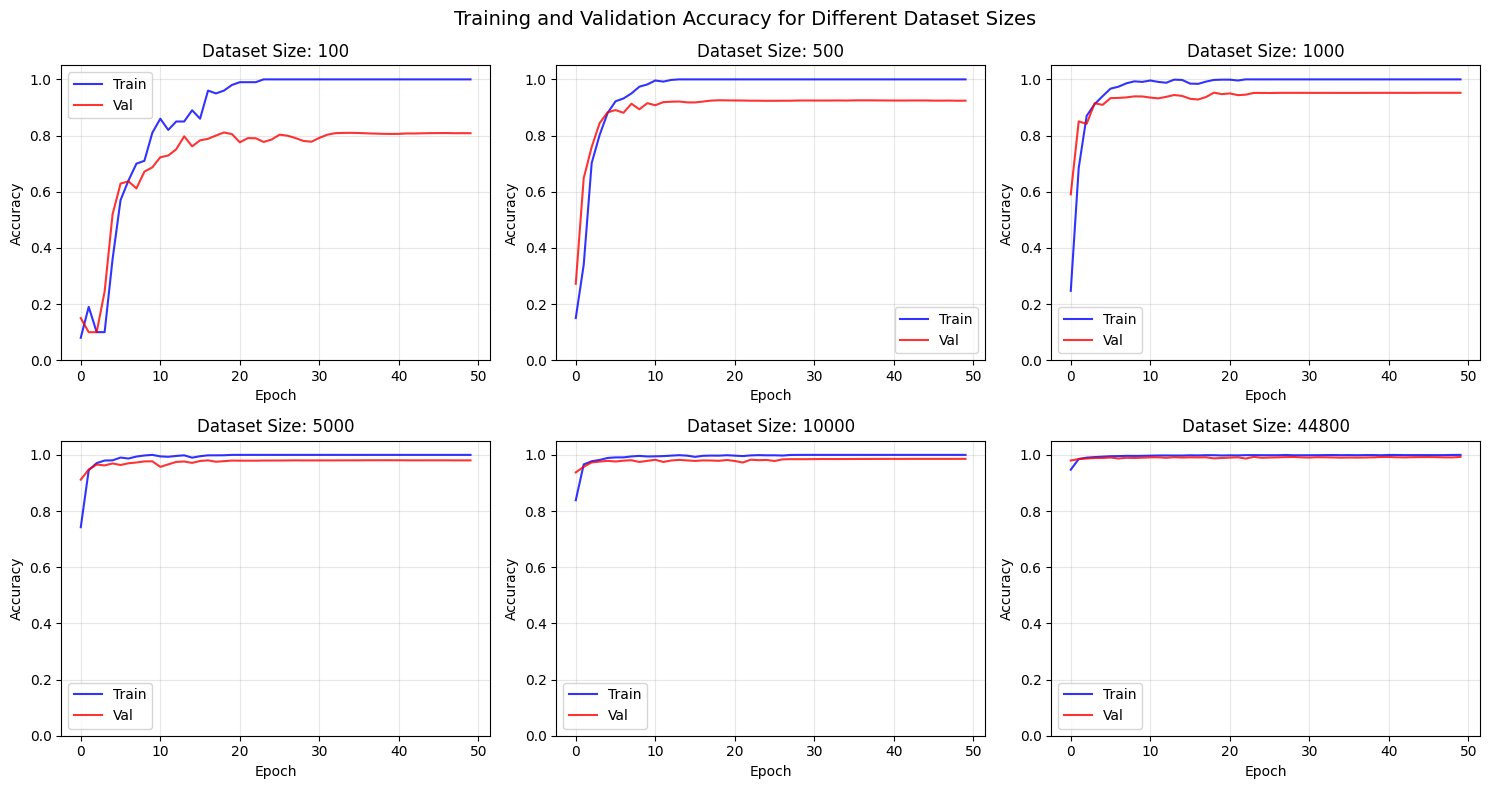

In [12]:
# Detailed training curves
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

plot_sizes = [100, 500, 1000, 5000, 10000, 44800]

for idx, size in enumerate(plot_sizes):
    if size in all_histories:
        ax = axes[idx]
        history = all_histories[size]
        
        ax.plot(history['train_acc'], 'b-', label='Train', alpha=0.8)
        ax.plot(history['val_acc'], 'r-', label='Val', alpha=0.8)
        ax.set_title(f'Dataset Size: {size}')
        ax.set_xlabel('Epoch')
        ax.set_ylabel('Accuracy')
        ax.legend()
        ax.grid(True, alpha=0.3)
        ax.set_ylim([0, 1.05])

plt.suptitle('Training and Validation Accuracy for Different Dataset Sizes', fontsize=14)
plt.tight_layout()
plt.savefig('outputs/mnist_small_dataset_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Summary and Conclusions

In [ ]:
print("\n" + "="*80)
print("KEY FINDINGS")
print("="*80)

# Find the threshold where performance drops significantly
for i, row in results_df.iterrows():
    size = row['dataset_size']
    test_acc = row['final_test_acc']
    train_acc = row['final_train_acc']
    gap = train_acc - test_acc
    
    status = ""
    if test_acc < 0.7:
        status = " <-- FAILING"
    elif test_acc < 0.85:
        status = " <-- STRUGGLING"
    elif test_acc < 0.95:
        status = " <-- MODERATE"
    else:
        status = " <-- GOOD"
    
    print(f"Size {size:>6}: Test Acc = {test_acc:.4f}, Gap = {gap:.4f}{status}")

# Find inflection points
print("\n" + "-"*80)
print("INFLECTION POINTS:")
print("-"*80)

thresholds = [0.7, 0.85, 0.9, 0.95, 0.98]
for thresh in thresholds:
    above_thresh = results_df[results_df['final_test_acc'] >= thresh]
    if len(above_thresh) > 0:
        min_size = above_thresh['dataset_size'].min()
        print(f"  To achieve >= {thresh*100:.0f}% test accuracy: need at least {min_size} samples")
    else:
        print(f"  To achieve >= {thresh*100:.0f}% test accuracy: not achieved in any experiment")

In [ ]:
# Save results to CSV
results_df.to_csv('outputs/mnist_small_dataset_results.csv', index=False)
print("\nResults saved to outputs/mnist_small_dataset_results.csv")